In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from kmeans import *
from gmm import *
from dbscan import *
from clustering_common import *

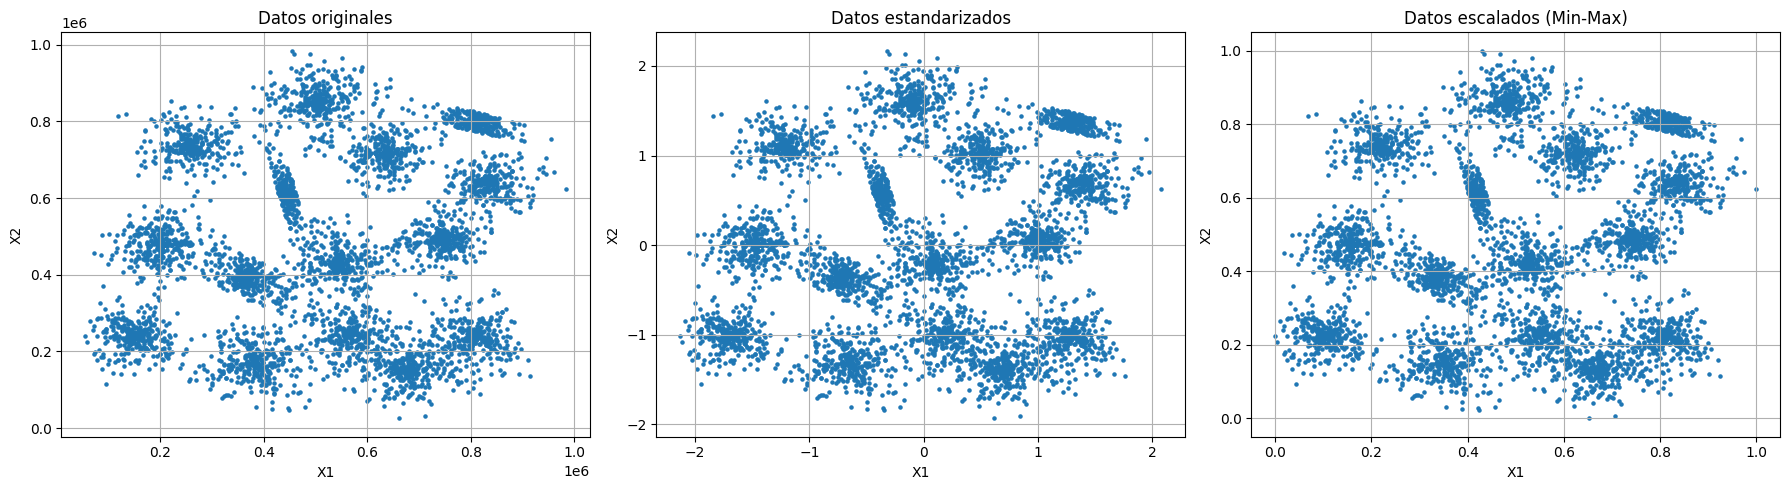

In [9]:
# Dataset para clustering
X = pd.read_csv('../data/clustering.csv').drop(columns=['Unnamed: 0']).values
# Normalización de los datos
X_estadarizado = escalar_estandar(X)  # escalado manual
X_escalado = escalar_minmax(X)

# Visualización inicial
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
data_sets = [X, X_estadarizado, X_escalado]
titles = ["Datos originales", "Datos estandarizados", "Datos escalados (Min-Max)"]

for i, (data, title) in enumerate(zip(data_sets, titles)):
    axes[i].scatter(data[:, 0], data[:, 1], s=5)
    axes[i].set_title(title)
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


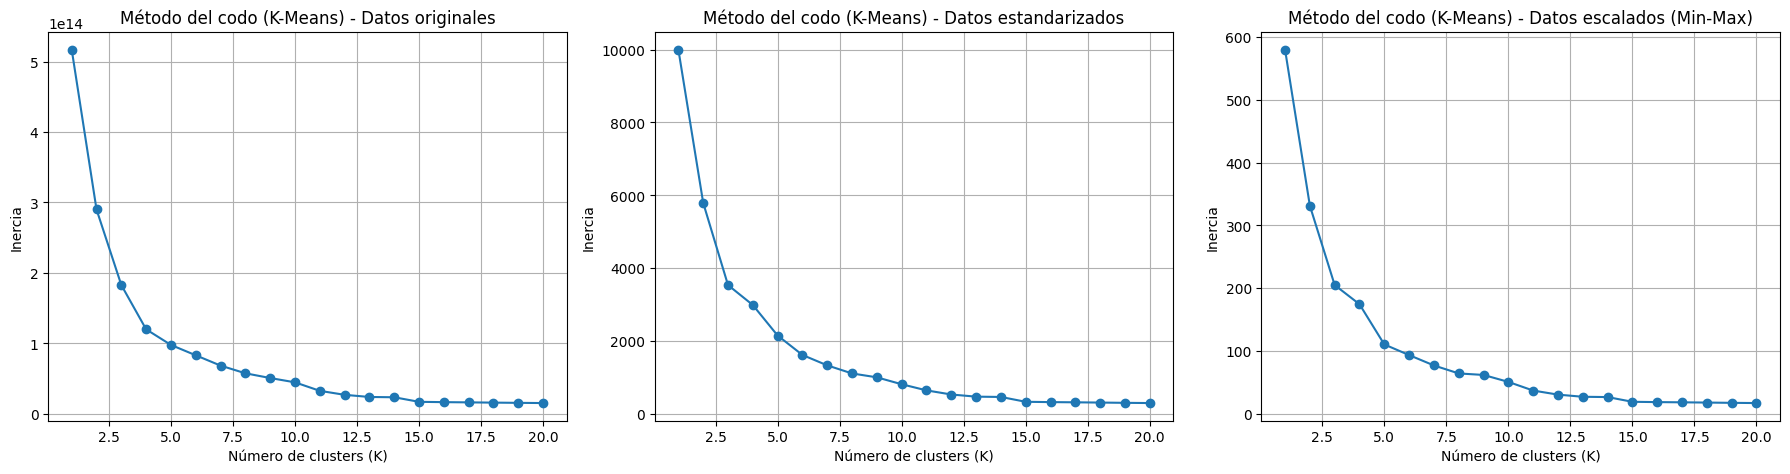

In [10]:
# Método del codo para los tres conjuntos de datos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
data_sets = [X, X_estadarizado, X_escalado]
titles = ["Datos originales", "Datos estandarizados", "Datos escalados (Min-Max)"]

for i, (data, title) in enumerate(zip(data_sets, titles)):
    inertias = [kmeans(data, k)[2] for k in range(1, 21)]
    axes[i].plot(range(1, 21), inertias, 'o-')
    axes[i].set_title(f"Método del codo (K-Means) - {title}")
    axes[i].set_xlabel("Número de clusters (K)")
    axes[i].set_ylabel("Inercia")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

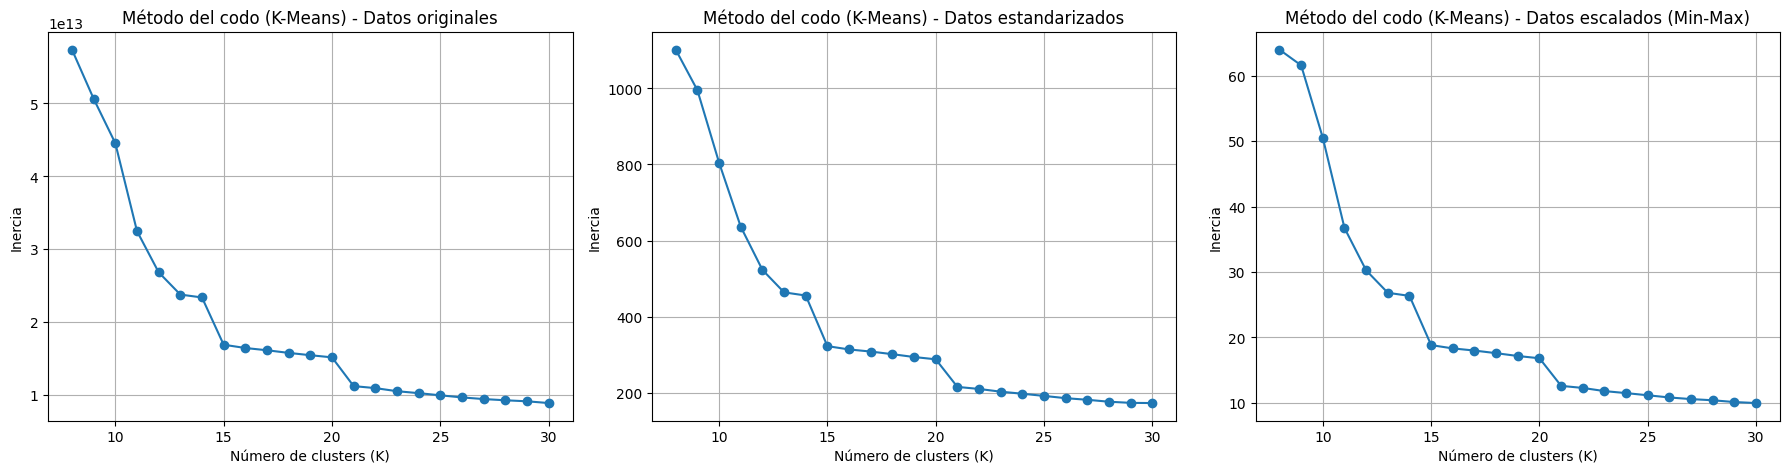

In [17]:
# Método del codo para los tres conjuntos de datos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
data_sets = [X, X_estadarizado, X_escalado]
titles = ["Datos originales", "Datos estandarizados", "Datos escalados (Min-Max)"]

for i, (data, title) in enumerate(zip(data_sets, titles)):
    inertias = [kmeans(data, k)[2] for k in range(8, 31)]
    axes[i].plot(range(8, 31), inertias, 'o-')
    axes[i].set_title(f"Método del codo (K-Means) - {title}")
    axes[i].set_xlabel("Número de clusters (K)")
    axes[i].set_ylabel("Inercia")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

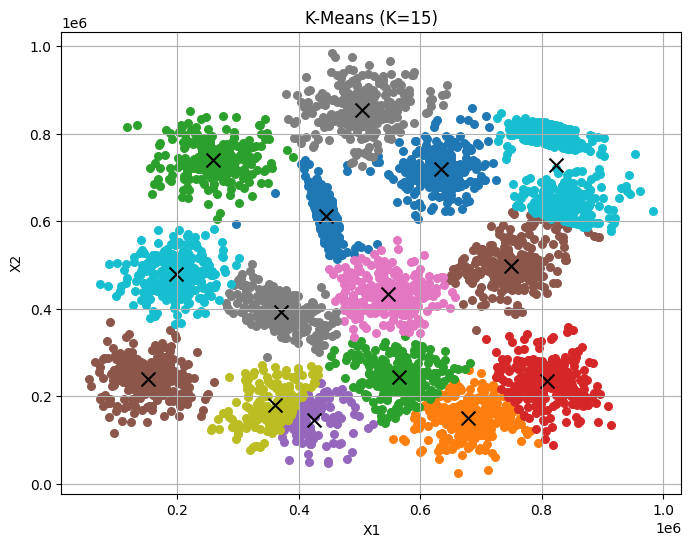

In [ ]:
k_opt = 15
centroides, etiquetas_kmeans, inercia = kmeans(X, k_opt)
fig = graficar_clusters(X, etiquetas_kmeans, centroides, titulo=f"K-Means (K={k_opt})")
plt.show()

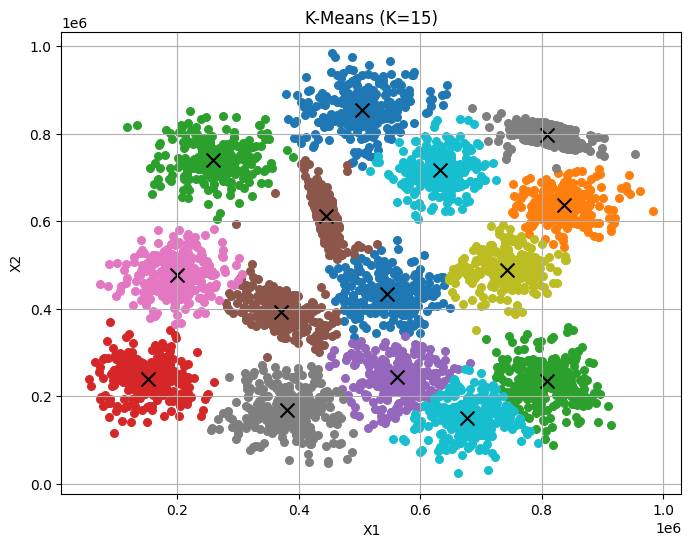

In [15]:
# Elegimos un valor K razonable (e.g., K = 15)
k_opt = 15
centroides, etiquetas_kmeans, inercia = iter_kmeans(X, k_opt, 1000, tries=200)
graficar_clusters(X, etiquetas_kmeans, centroides, titulo="K-Means (K=15)")

In [16]:
medias, covs, pesos, etiquetas_gmm = gmm(X, k_opt)
graficar_clusters(X, etiquetas_gmm, medias, titulo="GMM (K=3)")

KeyboardInterrupt: 

### Elección de hiperparámetros en DBSCAN

DBSCAN requiere dos hiperparámetros principales:

- **`eps`**: radio de vecindad
- **`min_pts`**: número mínimo de puntos en la vecindad para formar un núcleo

#### ➤ Caso sin escalar los datos
En el dataset original, las variables tienen distintas escalas (por ejemplo, `X2` puede alcanzar valores de hasta 1,000,000, mientras que `X1` varía en el rango de 0 a 5000). Como DBSCAN utiliza una métrica de distancia euclídea, la escala de los datos afecta fuertemente su desempeño. En este caso decidimos no escalar los datos, por lo que se ajustó el valor de `eps` manualmente.

Para lograr una buena separación de clusters y detección de ruido, se probó con diferentes valores de `eps`. Finalmente se seleccionó:

- `eps = 10000`
- `min_pts = 5`

Este valor permitió que DBSCAN identificara correctamente múltiples regiones densas como clusters, y al mismo tiempo clasificara puntos dispersos como ruido.

#### ➤ Alternativa: Escalado manual (sin sklearn)
También implementamos una función de normalización tipo Z-score (sin usar `sklearn`) para estandarizar los datos. En ese caso, se puede utilizar un valor de `eps = 0.5` con buenos resultados, ya que los datos están centrados en media 0 y desviación estándar 1.

#### ➤ Conclusión
En nuestro caso, se optó por trabajar directamente con los datos originales y adaptar `eps` a la escala del conjunto. Esto permitió obtener una segmentación natural del espacio, detectando regiones densas sin requerir una cantidad predefinida de clusters, y mostrando la capacidad de DBSCAN para trabajar con clusters de formas arbitrarias y detectar ruido.


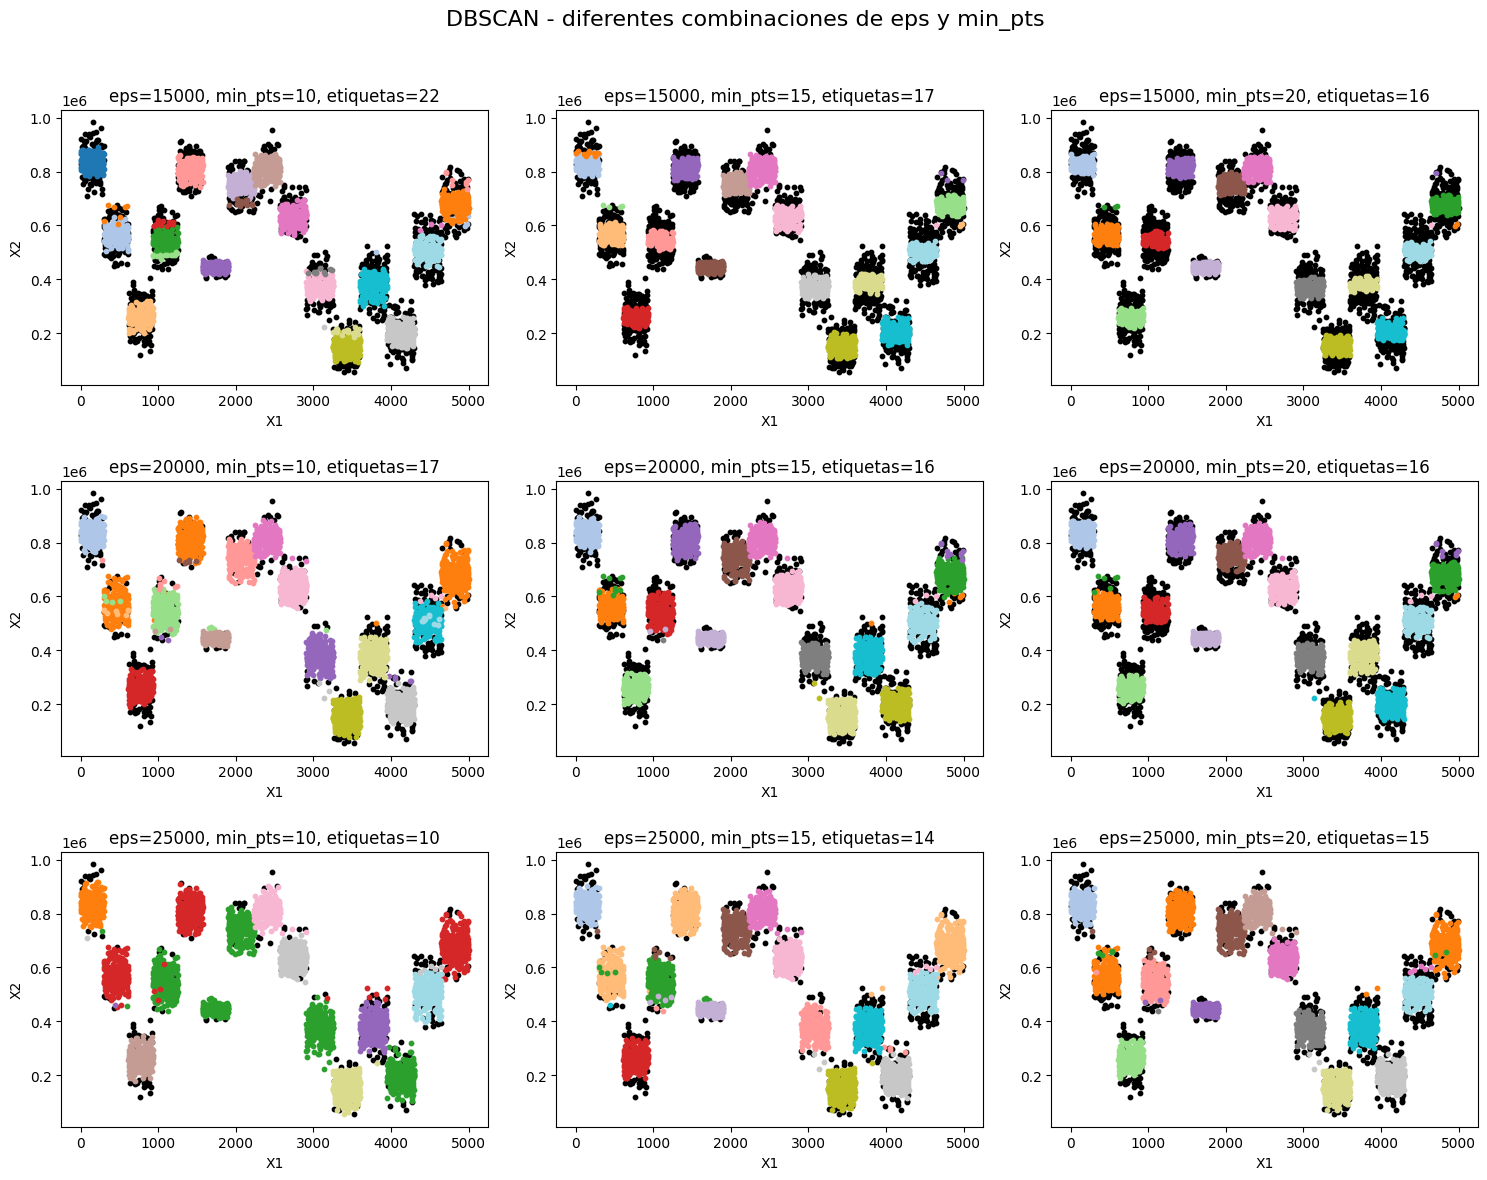

In [ ]:
# Definir valores a probar
eps_values = [15000, 20000, 25000]
min_pts_values = [10, 15, 20]

# Crear grilla de gráficos
fig, axs = plt.subplots(len(eps_values), len(min_pts_values), figsize=(15, 12))
fig.suptitle("DBSCAN - diferentes combinaciones de eps y min_pts", fontsize=16)

for i, eps in enumerate(eps_values):
    for j, min_pts in enumerate(min_pts_values):
        etiquetas = dbscan(X, eps, min_pts)
        ax = axs[i, j]
        etiquetas_unicas = np.unique(etiquetas)
        colores = plt.cm.tab20(np.linspace(0, 1, len(etiquetas_unicas)))
        for k, etiqueta in enumerate(etiquetas_unicas):
            puntos = X[etiquetas == etiqueta]
            color = 'black' if etiqueta == -1 else colores[k % len(colores)]
            ax.scatter(puntos[:, 0], puntos[:, 1], color=color, s=10)
        ax.set_title(f"eps={eps}, min_pts={min_pts}, etiquetas={len(etiquetas_unicas)}")
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

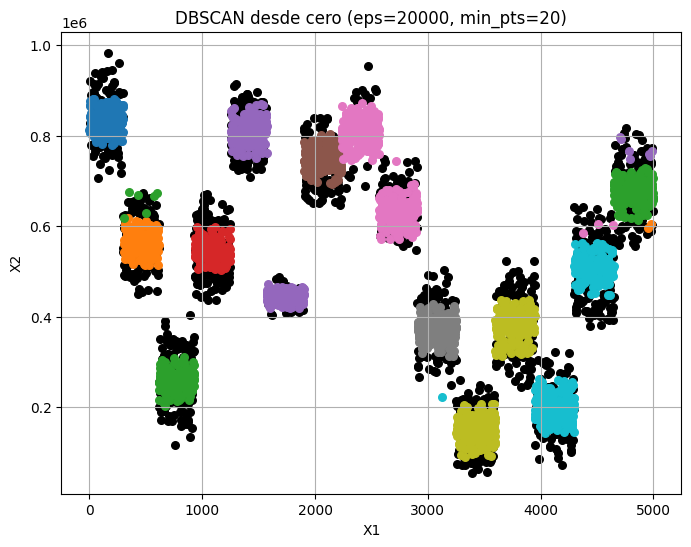

Número de clusters encontrados por DBSCAN: 15


In [ ]:
eps = 20000
min_pts = 20
etiquetas_dbscan = dbscan(X, eps, min_pts)
graficar_clusters(X, etiquetas_dbscan, titulo=f"DBSCAN (eps={eps}, min_pts={min_pts})")
print("Número de clusters encontrados por DBSCAN:", len(np.unique(etiquetas_dbscan)) - 1)  # -1 para excluir ruido

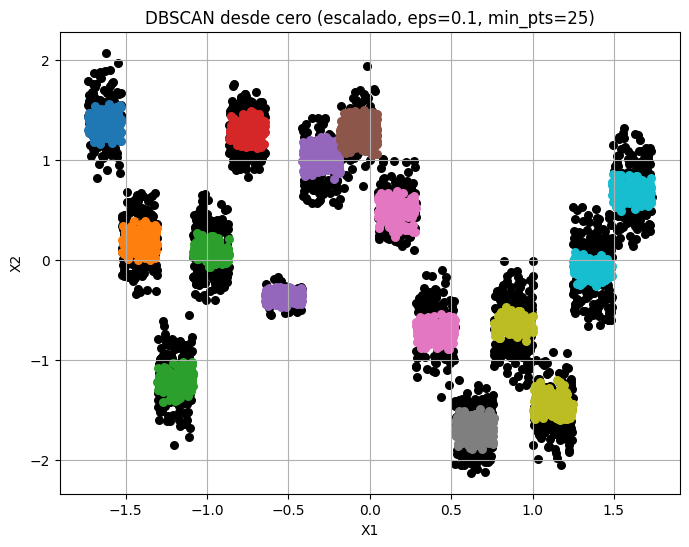

Número de clusters encontrados por DBSCAN (escalado): 15


In [ ]:
X_normalizado = escalar_estandar(X)  # escalado manual

eps = 0.1  # más chico ahora que los datos están escalados
min_pts = 25

etiquetas_dbscan = dbscan(X_normalizado, eps, min_pts)
graficar_clusters(X_normalizado, etiquetas_dbscan, titulo=f"DBSCAN (escalado, eps={eps}, min_pts={min_pts})")
print("Número de clusters encontrados por DBSCAN (escalado):", len(np.unique(etiquetas_dbscan)) - 1)  # -1 para excluir ruido
